<a href="https://colab.research.google.com/github/Harriet101-alt/Land_Appraisal/blob/main/Land_Appraisal_Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bellway North West — Land Appraisal Mapping

**Purpose:** Map the 2023 Housing Delivery Test (HDT) scores and mean house prices for every Local Planning Authority (LPA) in Bellway's North West and Manchester Divisions. These will be exported as GeoJSONs to be mapped on ArcGIS and form a land appraisal application.

**Data sources**
| Source | File | Description |
|--------|------|-------------|
| HDT scores | `Housing_Delivery_Test_2023_measurement.ods` | MHCLG official 2023 HDT release |
| Council boundaries | `May2025CouncilBoundaries.zip` | ONS LAD boundary shapefile (May 2025) |
| Residential House price | `House_Prices.csv` | Source: HM Land Registry (UK House Price Index). Dataset: Price Paid Data / Standardised House Price Index (2025). |

**Workflow**
1. `Config` — paths, constants, division membership
2. `HDTLoader` — reads & cleans the ODS file
3. `BoundaryLoader` — loads the shapefile
4. `NorthWestMapper` — joins HDT data → geometries, adds scoring labels
5. `HousePriceLoader` — reads & cleans house price CSV
6. `HousePriceMapper` — joins house price data → geometries
7. `MapPlotter` — renders the choropleth for HDT scores
8. `HousePricePlotter` — renders the choropleth for house prices
9. `GeoJSONExporter` — writes HDT output for ArcGIS / Landstack
10. `HousePriceGeoJSONExporter` — writes house price output for ArcGIS / Landstack

In [14]:
pip install odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 6.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=4a1359083257e0778340a168cc64ae7cd93b68a500bfc9956d54c548b16f84cc
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Standard library
from pathlib import Path

# Third-party
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


## 1 · Configuration

In [20]:
class Config:
    """Central place for every file path, constant, and LPA membership list.

    Change DRIVE_ROOT to point at your Google Drive (or local) folder.
    All other paths are derived from it.
    """

    # ── Paths ─────────────────────────────────────────────────────────────────
    DRIVE_ROOT          = Path("/content/drive/MyDrive")
    HDT_ODS_PATH        = DRIVE_ROOT / "Housing_Delivery_Test_2023_measurement.ods"
    HOUSE_PRICE         = DRIVE_ROOT / "House_Planning/House_Prices.csv"
    SHAPEFILE_PATH      = DRIVE_ROOT / "May2025CouncilBoundaries.zip"
    OUTPUT_GEOJSON      = DRIVE_ROOT / "NW_HDT_Map.geojson"
    OUTPUT_HOUSE_PRICE_GEOJSON = DRIVE_ROOT / "NW_House_Price_Map.geojson"

    # ── NPPF scoring thresholds ───────────────────────────────────────────────
    # HDT score is stored as a decimal (e.g. 0.95 = 95%)
    PRESUMPTION_THRESHOLD = 0.75   # < 75 % → Presumption in favour (worst)
    ACTION_PLAN_THRESHOLD = 0.85   # 75–85 % → Action Plan required
    BUFFER_THRESHOLD      = 0.95   # 85–95 % → 20 % buffer applies
    # ≥ 95 % → Pass (5 % buffer, no special consequence)

    # ── Division membership — corrected ONS LAD25 codes ──────────────────────
    MANCHESTER_DIVISION = {
        "E08000003": "Manchester",
        "E08000009": "Trafford",
        "E08000007": "Stockport",
        "E06000049": "Cheshire East",
        "E08000006": "Salford",
        "E08000001": "Bolton",
        "E08000002": "Bury",
        "E08000005": "Rochdale",
        "E08000004": "Oldham",
        "E08000008": "Tameside",
        "E07000121": "Lancaster",
        "E07000118": "Chorley",
        "E07000124": "Ribble Valley",
        "E07000123": "Preston",
        "E06000008": "Blackburn with Darwen",
        "E07000120": "Hyndburn",
        "E07000125": "Rossendale",
    }

    NORTH_WEST_DIVISION = {
        "E07000127": "West Lancashire",
        "E08000010": "Wigan",
        "E08000011": "Knowsley",
        "E07000126": "South Ribble",
        "E08000012": "Liverpool",
        "E08000014": "Sefton",
        "E08000013": "St. Helens",
        "E06000007": "Warrington",
        "E06000006": "Halton",
        "E08000015": "Wirral",
        "E06000050": "Cheshire West and Chester",
        "E07000128": "Wyre",
        "E07000119": "Fylde",
        "E06000009": "Blackpool",
    }

    # ── Colour palette (NPPF consequence) ─────────────────────────────────────
    CONSEQUENCE_COLOURS = {
        "Presumption": "#d73027",   # Red
        "Action plan": "#f46d43",   # Orange-red
        "Buffer":      "#fee090",   # Amber
        "Pass":        "#1a9850",   # Green
    }

    @classmethod
    def all_lpa_codes(cls) -> set:
        """Return the union of all tracked LPA codes."""
        return set(cls.MANCHESTER_DIVISION) | set(cls.NORTH_WEST_DIVISION)

    @classmethod
    def division_for(cls, ons_code: str) -> str:
        """Return the division name for a given ONS code, or 'Unknown'."""
        if ons_code in cls.MANCHESTER_DIVISION:
            return "Manchester"
        if ons_code in cls.NORTH_WEST_DIVISION:
            return "North West"
        return "Unknown"

## 2 · HDT Data Loader

In [8]:
class HDTLoader:
    """Reads and cleans the MHCLG Housing Delivery Test 2023 ODS file.

    The ODS has a multi-row header (rows 0-5 are metadata/header rows;
    actual data starts at row 6).  Column positions are fixed by the
    MHCLG publication layout.
    """

    # Fixed column positions in the ODS (0-indexed)
    _COL_MAP = {
        0:  "ONS_Code",
        1:  "Area_Name",
        2:  "Required_2020_21",
        3:  "Required_2021_22",
        4:  "Required_2022_23",
        5:  "Total_Required_3yr",
        6:  "Delivered_2020_21",
        7:  "Delivered_2021_22",
        8:  "Delivered_2022_23",
        9:  "Total_Delivered_3yr",
        10: "HDT_Score",          # decimal, e.g. 0.95
        11: "Consequence",        # string, e.g. "Buffer"
    }

    def __init__(self, ods_path: Path):
        self.ods_path = ods_path
        self._df: pd.DataFrame | None = None

    def load(self) -> "HDTLoader":
        """Read the ODS, keep only the 12 meaningful columns, rename them."""
        raw = pd.read_excel(
            self.ods_path,
            engine="odf",
            header=None,
            skiprows=6,          # skip the 6-row header block
            usecols=list(self._COL_MAP.keys()),
        )
        raw.rename(columns=self._COL_MAP, inplace=True)

        # Drop trailing metadata rows (those without a valid ONS code)
        raw = raw[raw["ONS_Code"].astype(str).str.match(r"^[EW]\d{8}$")].copy()

        # Ensure numeric columns are numeric
        numeric_cols = [c for c in raw.columns if c not in ("ONS_Code", "Area_Name", "Consequence")]
        raw[numeric_cols] = raw[numeric_cols].apply(pd.to_numeric, errors="coerce")

        # Tidy up HDT score: the file stores it as a decimal (e.g. 0.95 not 95)
        # Normalise — if any value > 5 it was probably stored as a percentage
        if raw["HDT_Score"].max() > 5:
            raw["HDT_Score"] = raw["HDT_Score"] / 100

        # Fill missing Consequence with "Pass"
        raw["Consequence"] = raw["Consequence"].fillna("Pass").str.strip().str.title()

        self._df = raw
        return self

    @property
    def data(self) -> pd.DataFrame:
        if self._df is None:
            raise RuntimeError("Call .load() first.")
        return self._df

    def filter_north_west(self) -> pd.DataFrame:
        """Return only the LPAs tracked by Bellway, with their division column."""
        nw_codes = Config.all_lpa_codes()
        df = self.data[self.data["ONS_Code"].isin(nw_codes)].copy()
        df["Division"] = df["ONS_Code"].map(Config.division_for)
        return df.reset_index(drop=True)


## 3 · Council Boundary Loader

In [9]:
class BoundaryLoader:
    """Loads the ONS LAD shapefile and projects to British National Grid."""

    TARGET_CRS = "EPSG:27700"   # British National Grid (metres)

    def __init__(self, shapefile_path: Path):
        self.shapefile_path = shapefile_path
        self._gdf: gpd.GeoDataFrame | None = None

    def load(self) -> "BoundaryLoader":
        gdf = gpd.read_file(self.shapefile_path)

        # Standardise the ONS code column name (the shapefile uses LAD25CD)
        if "LAD25CD" not in gdf.columns:
            raise KeyError(
                f"Expected column 'LAD25CD' in shapefile. Found: {list(gdf.columns)}"
            )

        gdf = gdf[["LAD25CD", "LAD25NM", "geometry"]].copy()
        gdf["LAD25CD"] = gdf["LAD25CD"].astype(str).str.strip()

        # Fix any self-intersections before dissolving later
        gdf["geometry"] = gdf.geometry.buffer(0)

        # Project to BNG
        gdf = gdf.to_crs(self.TARGET_CRS)

        self._gdf = gdf
        return self

    @property
    def data(self) -> gpd.GeoDataFrame:
        if self._gdf is None:
            raise RuntimeError("Call .load() first.")
        return self._gdf


## 4 · North West Mapper

In [31]:
class NorthWestMapper:
    """Joins HDT data to council geometries and adds derived fields."""

    def __init__(self, hdt_df: pd.DataFrame, boundaries: gpd.GeoDataFrame):
        self.hdt_df = hdt_df
        self.boundaries = boundaries
        self._joined: gpd.GeoDataFrame | None = None
        self._division_outlines: gpd.GeoDataFrame | None = None

    def build(self) -> "NorthWestMapper":
        # Inner join on ONS code
        joined = self.boundaries.merge(
            self.hdt_df,
            left_on="LAD25CD",
            right_on="ONS_Code",
            how="inner",
        )

        if joined.empty:
            raise ValueError(
                "Join produced zero rows — check that ONS codes match "
                "between the ODS file and the shapefile."
            )

        # Colour column (for plotting)
        joined["colour"] = joined["Consequence"].map(Config.CONSEQUENCE_COLOURS)
        joined["colour"] = joined["colour"].fillna(Config.CONSEQUENCE_COLOURS["Pass"])

        # Score as percentage string for labels
        joined["HDT_Pct"] = (joined["HDT_Score"] * 100).round(0).astype(int).astype(str) + "%"

        self._joined = joined

        # Dissolve to get thick division outlines
        self._division_outlines = joined.dissolve(by="Division")

        return self

    # ── Diagnostics ───────────────────────────────────────────────────────────
    def report_missing(self) -> None:
        """Print any tracked LPAs that could not be joined to a geometry."""
        expected = Config.all_lpa_codes()
        found = set(self._joined["LAD25CD"])
        missing = expected - found
        if missing:
            print(f"⚠️  Missing from map ({len(missing)}):")
            for code in sorted(missing):
                name = {**Config.MANCHESTER_DIVISION, **Config.NORTH_WEST_DIVISION}.get(code, "?")
                print(f"   {code}  {name}")
        else:
            print(f"✅  All {len(expected)} LPAs successfully joined.")

    @property
    def joined(self) -> gpd.GeoDataFrame:
        if self._joined is None:
            raise RuntimeError("Call .build() first.")
        return self._joined

    @property
    def division_outlines(self) -> gpd.GeoDataFrame:
        if self._division_outlines is None:
            raise RuntimeError("Call .build() first.")
        return self._division_outlines


class HousePriceLoader:
    """Reads the House Prices CSV and calculates mean prices by ONS code."""

    # Assumed column names in the input CSV file `House_Prices.csv`.
    # 'AreaCode' is mapped to 'ONS_Code' for consistency with other data sources.
    # 'AveragePrice' is mapped to 'House_Price_Mean' as we're calculating mean prices.
    _COL_MAP = {
        "AreaCode": "ONS_Code",
        "AveragePrice": "House_Price_Mean"
    }

    def __init__(self, csv_path: Path):
        self.csv_path = csv_path
        self._df: pd.DataFrame | None = None

    def load(self) -> "HousePriceLoader":
        raw = pd.read_csv(self.csv_path)

        # Check if the expected input columns are present before renaming
        for original_col, target_col in self._COL_MAP.items():
            if original_col not in raw.columns:
                raise KeyError(f"Expected column '{original_col}' (to be mapped to '{target_col}') not found in the CSV file '{self.csv_path}'. "
                               f"Please ensure the CSV has a column for ONS codes (e.g., 'AreaCode') and prices (e.g., 'AveragePrice').")

        # Rename columns based on the mapping
        raw.rename(columns=self._COL_MAP, inplace=True)

        # Ensure ONS_Code is consistent (strip whitespace)
        raw["ONS_Code"] = raw["ONS_Code"].astype(str).str.strip()

        # Convert 'House_Price_Mean' to numeric, coercing errors to NaN, then drop NaNs
        raw['House_Price_Mean'] = pd.to_numeric(raw['House_Price_Mean'], errors='coerce')
        raw.dropna(subset=['House_Price_Mean'], inplace=True)

        # Group by ONS_Code and calculate the mean for 'House_Price_Mean'
        # This handles cases where there might be multiple entries for the same ONS_Code
        # and we want the mean of these entries.
        mean_prices_df = raw.groupby("ONS_Code")["House_Price_Mean"].mean().reset_index()

        self._df = mean_prices_df
        return self

    @property
    def data(self) -> pd.DataFrame:
        if self._df is None:
            raise RuntimeError("Call .load() first.")
        return self._df

    def filter_north_west(self) -> pd.DataFrame:
        """Return only the LPAs tracked by Bellway, with their division column."""
        nw_codes = Config.all_lpa_codes()
        df = self.data[self.data["ONS_Code"].isin(nw_codes)].copy()
        df["Division"] = df["ONS_Code"].map(Config.division_for)
        return df.reset_index(drop=True)


class HousePriceMapper:
    """Joins house price data to council geometries and adds derived fields."""

    def __init__(self, house_price_df: pd.DataFrame, boundaries: gpd.GeoDataFrame):
        self.house_price_df = house_price_df
        self.boundaries = boundaries
        self._joined: gpd.GeoDataFrame | None = None

    def build(self) -> "HousePriceMapper":
        # Inner join on ONS code
        joined = self.boundaries.merge(
            self.house_price_df,
            left_on="LAD25CD",
            right_on="ONS_Code",
            how="inner",
        )

        if joined.empty:
            raise ValueError(
                "Join produced zero rows — check that ONS codes match "
                "between the house price file and the shapefile.")

        self._joined = joined
        return self

    @property
    def joined(self) -> gpd.GeoDataFrame:
        if self._joined is None:
            raise RuntimeError("Call .build() first.")
        return self._joined

## 5 · Map Plotter

In [39]:
class MapPlotter:
    """Renders a choropleth coloured by NPPF consequence."""

    def __init__(self, mapper: NorthWestMapper):
        self.mapper = mapper

    def plot(self, title: str = "Bellway North West — Housing Delivery Test 2023") -> None:
        gdf  = self.mapper.joined
        divs = self.mapper.division_outlines

        fig, ax = plt.subplots(figsize=(14, 18))

        # ── 1. Council fill (HDT consequence colour) ──────────────────────────
        gdf.plot(
            ax=ax,
            color=gdf["colour"],
            edgecolor="white",
            linewidth=0.5,
            alpha=0.85,
        )

        # ── 2. Division boundary outlines ─────────────────────────────────────
        divs.plot(
            ax=ax,
            facecolor="none",
            edgecolor="black",
            linewidth=3.5,
        )

        # ── 3. Council name + HDT score labels ────────────────────────────────
        for _, row in gdf.iterrows():
            pt = row.geometry.representative_point()
            label = f"{row['Area_Name']}\n{row['HDT_Pct']}"
            ax.annotate(
                label,
                xy=(pt.x, pt.y),
                ha="center",
                fontsize=7,
                fontweight="bold",
                color="black",
                bbox=dict(facecolor="white", alpha=0.55, edgecolor="none", pad=1),
            )

        # ── 4. Legend ─────────────────────────────────────────────────────────
        legend_items = [
            mpatches.Patch(color=colour, label=consequence)
            for consequence, colour in Config.CONSEQUENCE_COLOURS.items()
        ]
        ax.legend(
            handles=legend_items,
            title="NPPF Consequence",
            loc="lower left",
            fontsize=10,
            title_fontsize=11,
            framealpha=0.9,
        )

        ax.set_title(title, fontsize=18, pad=16)
        ax.axis("off")
        plt.tight_layout()
        plt.show()


class HousePricePlotter:
    """Renders a choropleth of house prices."""

    def __init__(self, mapper: HousePriceMapper):
        self.mapper = mapper

    def plot(self, title: str = "Bellway North West — Mean House Prices") -> None:
        gdf = self.mapper.joined

        fig, ax = plt.subplots(1, 1, figsize=(14, 14))

        # Plotting the choropleth map
        gdf.plot(
            column='House_Price_Mean',
            cmap='viridis_r',  # Viridis_r for higher values to be brighter
            linewidth=0.8,
            ax=ax,
            edgecolor='0.8',
            legend=True,
            legend_kwds={'label': "Mean House Price (£)", 'orientation': "horizontal"}
        )

        # Add council names and house prices as labels
        for idx, row in gdf.iterrows():
            pt = row.geometry.representative_point()
            # Corrected format specifier: removed space before ',.0f'
            label = f"{row['LAD25NM']}\n£{row['House_Price_Mean']:,.0f}"
            ax.annotate(
                label,
                xy=(pt.x, pt.y),
                xytext=(3, 3), # Offset label slightly
                textcoords="offset points",
                ha="center",
                fontsize=7,
                fontweight="bold",
                color="black",
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1),
            )

        ax.set_title(title, fontsize=18, pad=16)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## 6 · GeoJSON Exporter

In [37]:
class GeoJSONExporter:
    """Exports the joined GeoDataFrame to a Landstack / ArcGIS-ready GeoJSON."""

    # Properties to include in the GeoJSON feature properties
    EXPORT_COLUMNS = [
        "geometry",
        "LAD25CD",
        "Area_Name",
        "Division",
        "HDT_Score",
        "HDT_Pct",
        "Consequence",
        "colour",
        "Total_Required_3yr",
        "Total_Delivered_3yr",
        "Required_2020_21",
        "Required_2021_22",
        "Required_2022_23",
        "Delivered_2020_21",
        "Delivered_2021_22",
        "Delivered_2022_23",
    ]

    def __init__(self, mapper: NorthWestMapper, output_path: Path):
        self.mapper = mapper
        self.output_path = output_path

    def export(self) -> None:
        gdf = self.mapper.joined[self.EXPORT_COLUMNS].copy()

        # GeoJSON must be in WGS84 (EPSG:4326)
        gdf = gdf.to_crs("EPSG:4326")

        # Rename colour → fill so Mapbox / Landstack picks it up automatically
        gdf = gdf.rename(columns={"colour": "fill"})

        gdf.to_file(self.output_path, driver="GeoJSON")
        print(f"✅  Exported {len(gdf)} councils → {self.output_path}")


class HousePriceGeoJSONExporter:
    """Exports the joined House Price GeoDataFrame to a Landstack / ArcGIS-ready GeoJSON."""

    # Properties to include in the GeoJSON feature properties
    EXPORT_COLUMNS = [
        "geometry",
        "LAD25CD",
        "LAD25NM",
        "ONS_Code",
        "House_Price_Mean",
        "Division",
    ]

    def __init__(self, mapper: HousePriceMapper, output_path: Path):
        self.mapper = mapper
        self.output_path = output_path

    def export(self) -> None:
        gdf = self.mapper.joined[self.EXPORT_COLUMNS].copy()

        # GeoJSON must be in WGS84 (EPSG:4326)
        gdf = gdf.to_crs("EPSG:4326")

        gdf.to_file(self.output_path, driver="GeoJSON")
        print(f"✅  Exported {len(gdf)} house price records → {self.output_path}")


## 7 · Run the Full Pipeline

In [15]:
# ── Step 1: Load HDT data from the ODS file ───────────────────────────────────
hdt_loader = HDTLoader(Config.HDT_ODS_PATH)
hdt_loader.load()

nw_hdt = hdt_loader.filter_north_west()
print(f"HDT records loaded: {len(nw_hdt)}")
nw_hdt[["ONS_Code", "Area_Name", "Division", "HDT_Score", "Consequence"]].head(10)


HDT records loaded: 31


,ONS_Code,Area_Name,Division,HDT_Score,Consequence
0,E06000008,Blackburn with Darwen,Manchester,0.0359,Pass
1,E06000009,Blackpool,North West,0.0250,Pass
2,E08000001,Bolton,Manchester,0.0094,Action Plan
3,E08000002,Bury,Manchester,0.0064,Presumption
4,E06000049,Cheshire East,Manchester,0.0262,Pass
5,E06000050,Cheshire West and Chester,North West,0.0275,Pass
6,E07000118,Chorley,Manchester,0.0057,Presumption
7,E07000119,Fylde,North West,0.0176,Pass
8,E06000006,Halton,North West,0.0081,Buffer
9,E07000120,Hyndburn,Manchester,0.0409,Pass


In [16]:
# ── Step 2: Load council boundaries ──────────────────────────────────────────
boundary_loader = BoundaryLoader(Config.SHAPEFILE_PATH)
boundary_loader.load()

print(f"Boundary polygons loaded: {len(boundary_loader.data)}")
boundary_loader.data.head(3)


Boundary polygons loaded: 361


,LAD25CD,LAD25NM,geometry
0,E06000001,Hartlepool,"MULTIPOLYGON (((447213.9 537036.104, 447228.79..."
1,E06000002,Middlesbrough,"MULTIPOLYGON (((448609.9 521982.6, 448616.85 5..."
2,E06000003,Redcar and Cleveland,"MULTIPOLYGON (((455741.497 528178.955, 455741...."


In [17]:
# ── Step 3: Join data to geometries ──────────────────────────────────────────
mapper = NorthWestMapper(nw_hdt, boundary_loader.data)
mapper.build()
mapper.report_missing()


✅  All 31 LPAs successfully joined.


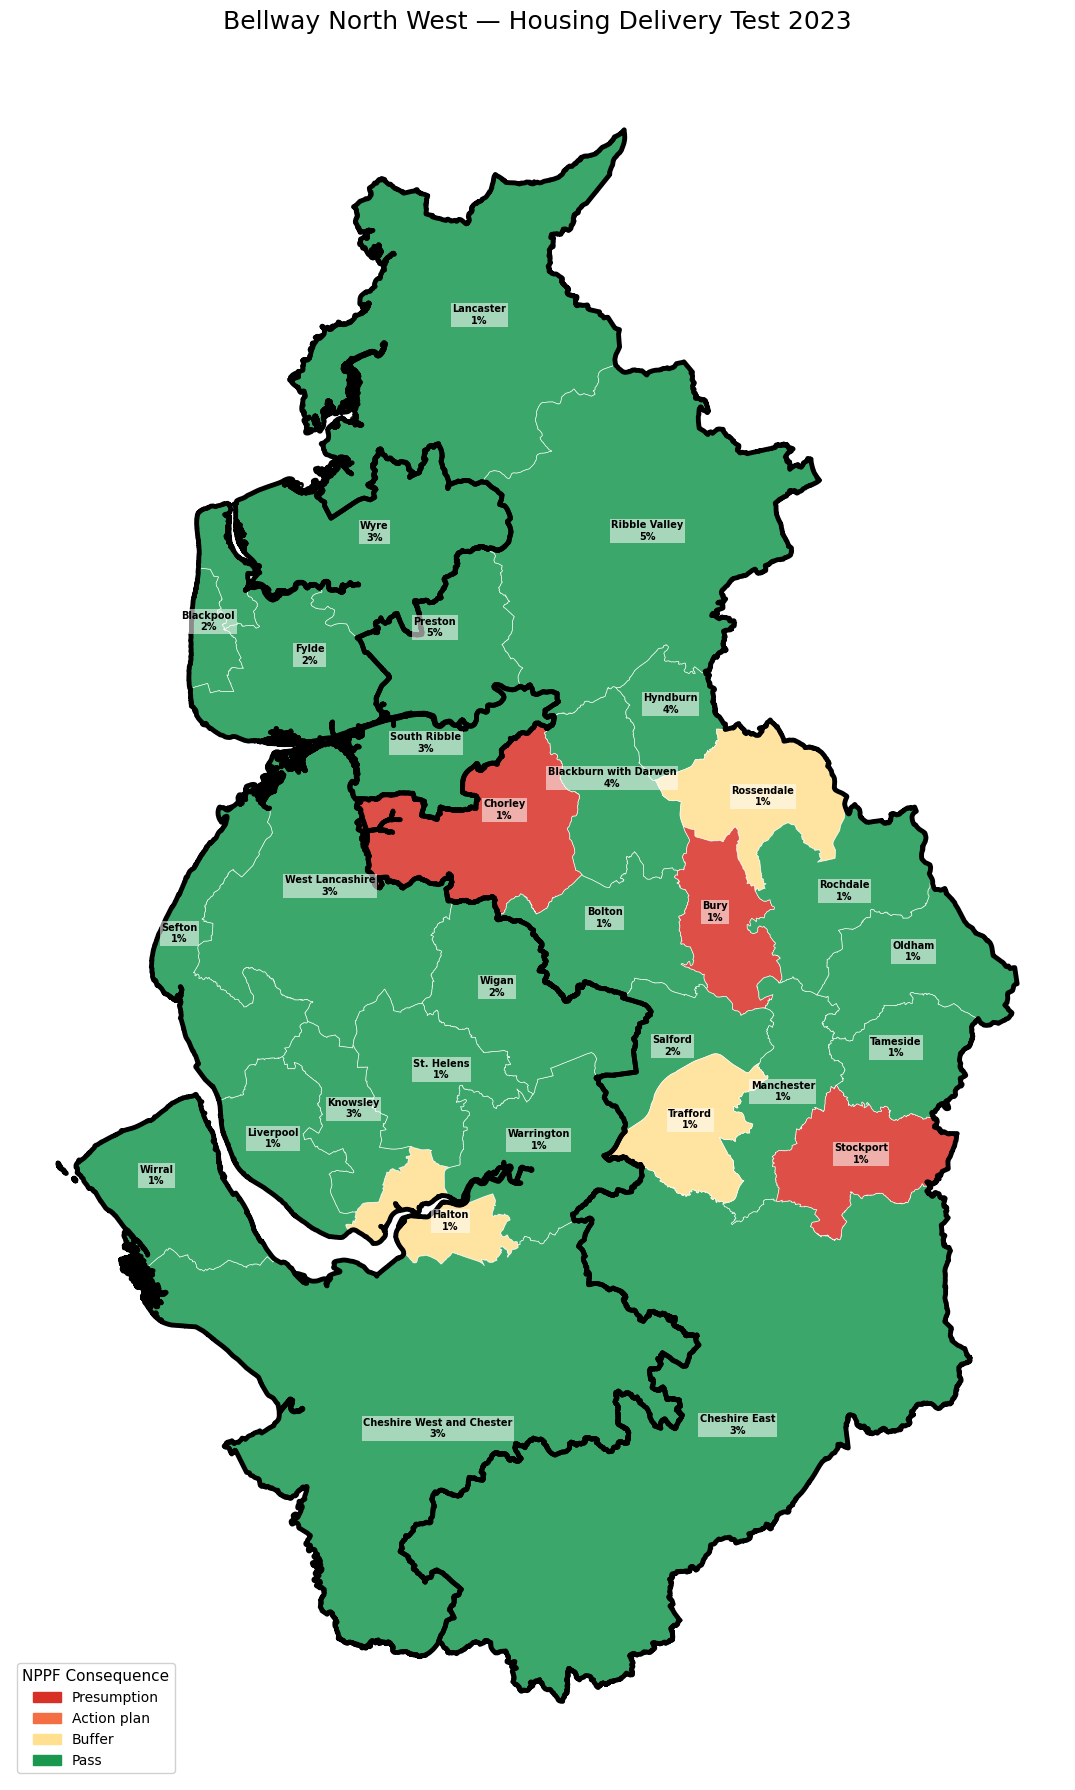

In [18]:
# ── Step 4: Plot the map ──────────────────────────────────────────────────────
plotter = MapPlotter(mapper)
plotter.plot()


In [19]:
# ── Step 5: Export GeoJSON ────────────────────────────────────────────────────
exporter = GeoJSONExporter(mapper, Config.OUTPUT_GEOJSON)
exporter.export()


✅  Exported 31 councils → /content/drive/MyDrive/NW_HDT_Map.geojson


In [28]:
# Inspect the House_Prices.csv file to find the correct ONS code column
import pandas as pd

house_price_csv_path = Config.HOUSE_PRICE

try:
    temp_df = pd.read_csv(house_price_csv_path)
    print(f"Columns in '{house_price_csv_path}':")
    print(temp_df.columns.tolist())
    print("\nFirst 5 rows:")
    display(temp_df.head())
except FileNotFoundError:
    print(f"Error: The file '{house_price_csv_path}' was not found. Please ensure the path is correct.")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")


Columns in '/content/drive/MyDrive/House_Planning/House_Prices.csv':
['Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', 'IndexSA', '1m%Change', '12m%Change', 'AveragePriceSA', 'SalesVolume', 'DetachedPrice', 'DetachedIndex', 'Detached1m%Change', 'Detached12m%Change', 'SemiDetachedPrice', 'SemiDetachedIndex', 'SemiDetached1m%Change', 'SemiDetached12m%Change', 'TerracedPrice', 'TerracedIndex', 'Terraced1m%Change', 'Terraced12m%Change', 'FlatPrice', 'FlatIndex', 'Flat1m%Change', 'Flat12m%Change', 'CashPrice', 'CashIndex', 'Cash1m%Change', 'Cash12m%Change', 'CashSalesVolume', 'MortgagePrice', 'MortgageIndex', 'Mortgage1m%Change', 'Mortgage12m%Change', 'MortgageSalesVolume', 'FTBPrice', 'FTBIndex', 'FTB1m%Change', 'FTB12m%Change', 'FOOPrice', 'FOOIndex', 'FOO1m%Change', 'FOO12m%Change', 'NewPrice', 'NewIndex', 'New1m%Change', 'New12m%Change', 'NewSalesVolume', 'OldPrice', 'OldIndex', 'Old1m%Change', 'Old12m%Change', 'OldSalesVolume']

First 5 rows:


,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [38]:
# ── Step 6: Load and Map House Price Data ──────────────────────────────────────
house_price_loader = HousePriceLoader(Config.HOUSE_PRICE)
house_price_loader.load()

nw_house_prices = house_price_loader.filter_north_west()
print(f"House price records loaded and filtered: {len(nw_house_prices)}")

house_price_mapper = HousePriceMapper(nw_house_prices, boundary_loader.data)
house_price_mapper.build()

# ── Step 7: Export House Price GeoJSON ────────────────────────────────────────
house_price_exporter = HousePriceGeoJSONExporter(house_price_mapper, Config.OUTPUT_HOUSE_PRICE_GEOJSON)
house_price_exporter.export()

print("House price GeoJSON pipeline completed.")

House price records loaded and filtered: 31
✅  Exported 31 house price records → /content/drive/MyDrive/NW_House_Price_Map.geojson
House price GeoJSON pipeline completed.


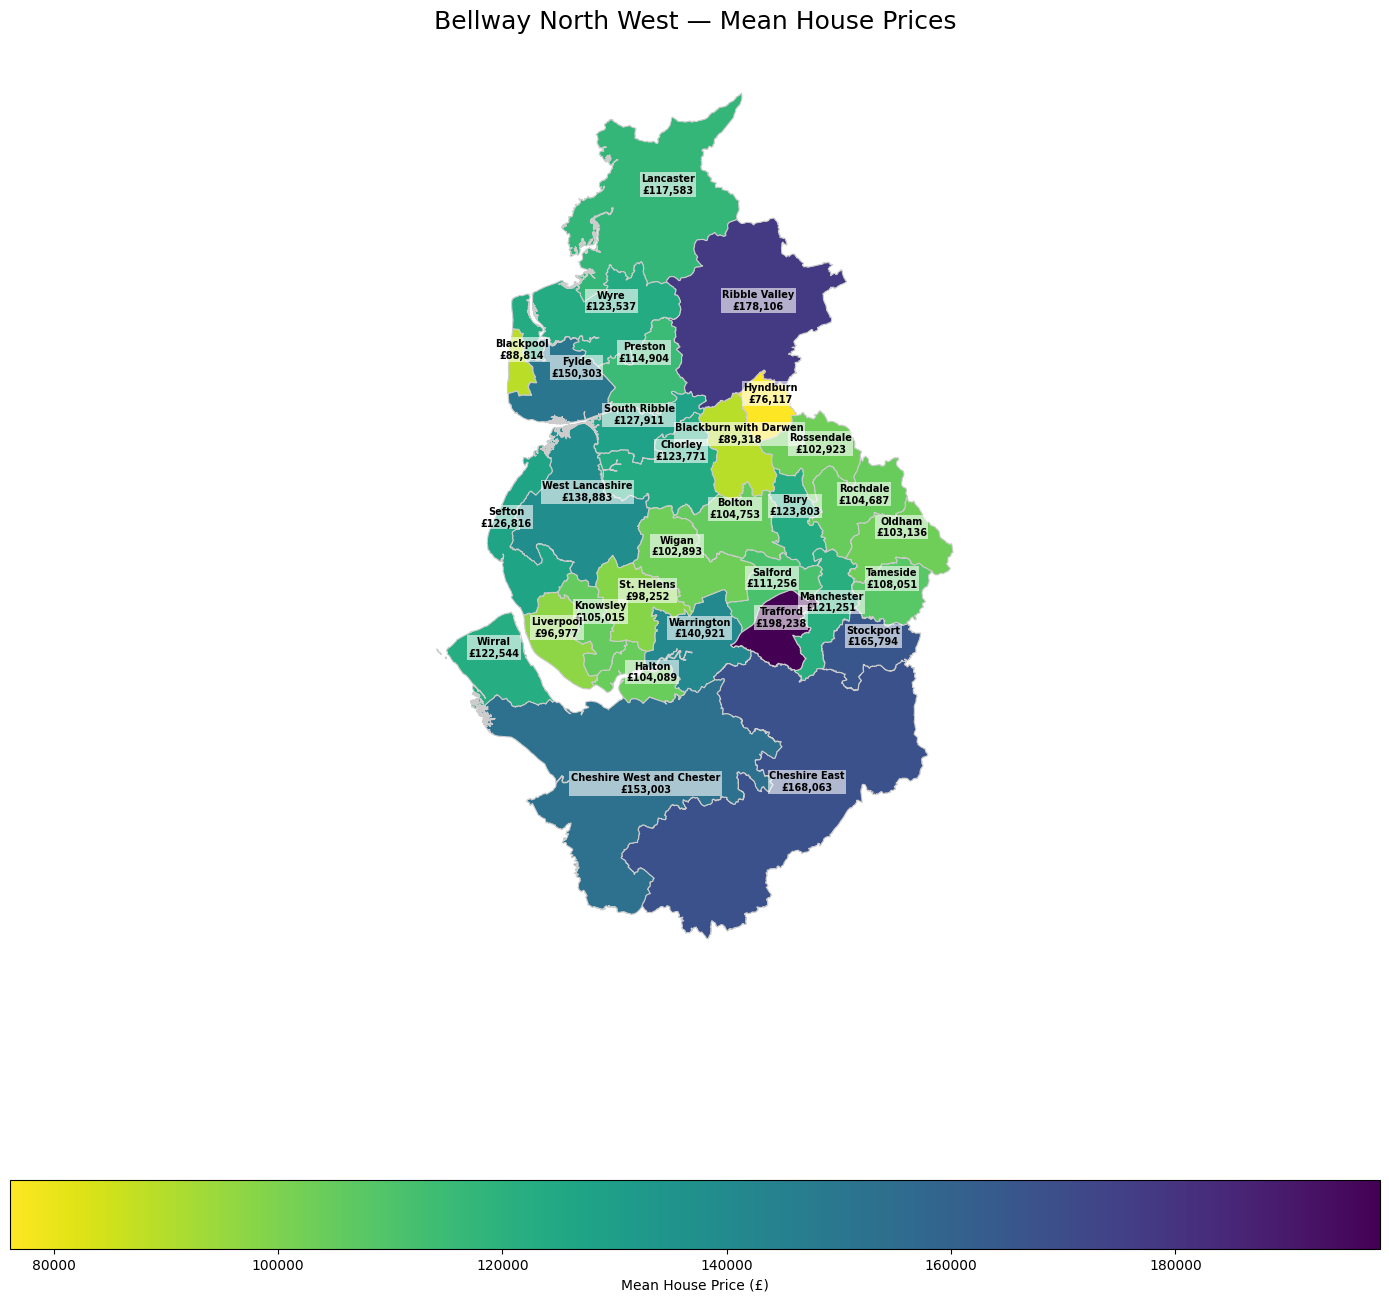

In [40]:
# ── Step 8: Plot the House Price Map ───────────────────────────────────────
house_price_plotter = HousePricePlotter(house_price_mapper)
house_price_plotter.plot()

## 8 · Summary Table

In [ ]:
# Quick-reference table sorted by HDT score (worst first)
summary = mapper.joined[[
    "Area_Name", "Division", "HDT_Score", "HDT_Pct", "Consequence",
    "Total_Required_3yr", "Total_Delivered_3yr"
]].copy()

summary["HDT_Score"] = summary["HDT_Score"].round(2)
summary["Total_Required_3yr"] = summary["Total_Required_3yr"].round(0).astype(int)
summary["Total_Delivered_3yr"] = summary["Total_Delivered_3yr"].round(0).astype(int)

summary.sort_values("HDT_Score").reset_index(drop=True).style \
    .background_gradient(subset=["HDT_Score"], cmap="RdYlGn") \
    .set_caption("Housing Delivery Test 2023 — Bellway North West & Manchester Divisions")


,Area_Name,Division,HDT_Score,HDT_Pct,Consequence,Total_Required_3yr,Total_Delivered_3yr
0,Halton,North West,0.010000,1%,Buffer,637,517
1,Warrington,North West,0.010000,1%,Pass,1926,2789
2,Chorley,Manchester,0.010000,1%,Presumption,1458,826
3,Lancaster,Manchester,0.010000,1%,Pass,1115,1149
4,Rossendale,Manchester,0.010000,1%,Buffer,496,405
5,Sefton,North West,0.010000,1%,Pass,1634,2371
6,Liverpool,North West,0.010000,1%,Pass,4313,5097
7,Wirral,North West,0.010000,1%,Pass,2064,1979
8,Trafford,Manchester,0.010000,1%,Buffer,3105,2415
9,Tameside,Manchester,0.010000,1%,Pass,1320,1294
